<a href="https://colab.research.google.com/github/wanchenlang-max/econ5200-lab/blob/lab16/lab16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wbgapi -q

import pandas as pd
import numpy as np
import wbgapi as wb
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, lasso_path

In [2]:

indicators = [
    'NY.GDP.MKTP.KD.ZG',
    'FP.CPI.TOTL.ZG',
    'BX.KLT.DINV.WD.GD.ZS',
    'NE.TRD.GNFS.ZS',
    'GC.DOD.TOTL.GD.ZS',
    'SL.UEM.TOTL.ZS'
]

print("Querying World Bank API...")


df_api = wb.data.DataFrame(indicators, time=2022, skipBlanks=True, columns='series')

df_clean = df_api.dropna()

y = df_clean['NY.GDP.MKTP.KD.ZG']
X_raw = df_clean.drop(columns=['NY.GDP.MKTP.KD.ZG'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"API Ingestion Complete. Feature matrix shape: {X_scaled.shape}")

Querying World Bank API...
API Ingestion Complete. Feature matrix shape: (41, 5)


In [3]:


ols_model = LinearRegression().fit(X_scaled, y)

print("--- OLS REGRESSION RESULTS ---")
print(f"Standard OLS Training R-squared: {ols_model.score(X_scaled, y):.4f}")
print("Notice how the model effectively 'memorizes' the dataset.")

--- OLS REGRESSION RESULTS ---
Standard OLS Training R-squared: 0.1007
Notice how the model effectively 'memorizes' the dataset.


In [4]:

alphas_to_test = np.logspace(-3, 4, 100)
ridge_model = RidgeCV(alphas=alphas_to_test, cv=5).fit(X_scaled, y)

print("--- RIDGE REGRESSION RESULTS ---")
print(f"Optimal L2 Penalty (Alpha): {ridge_model.alpha_:.4f}")

zeros_in_ridge = np.sum(ridge_model.coef_ == 0)
print(f"Number of coefficients driven to exactly 0 by Ridge: {zeros_in_ridge} out of {X_raw.shape[1]}")

--- RIDGE REGRESSION RESULTS ---
Optimal L2 Penalty (Alpha): 10000.0000
Number of coefficients driven to exactly 0 by Ridge: 0 out of 5


In [5]:

lasso_model = LassoCV(cv=5, random_state=42, max_iter=10000).fit(X_scaled, y)

print("--- LASSO REGRESSION RESULTS ---")
print(f"Optimal L1 Penalty (Alpha): {lasso_model.alpha_:.4f}")

surviving_features = np.sum(lasso_model.coef_ != 0)
eliminated_features = np.sum(lasso_model.coef_ == 0)

print(f"\nFeatures Retained (Signal): {surviving_features}")
print(f"Features Eliminated (Noise): {eliminated_features}")

active_vars = X_raw.columns[lasso_model.coef_ != 0]

print("\nTop Surviving Macroeconomic Indicators:")
for var, coef in zip(active_vars, lasso_model.coef_[lasso_model.coef_ != 0]):
    print(f"{var}: {coef:.4f}")

--- LASSO REGRESSION RESULTS ---
Optimal L1 Penalty (Alpha): 0.7134

Features Retained (Signal): 1
Features Eliminated (Noise): 4

Top Surviving Macroeconomic Indicators:
SL.UEM.TOTL.ZS: 0.0000


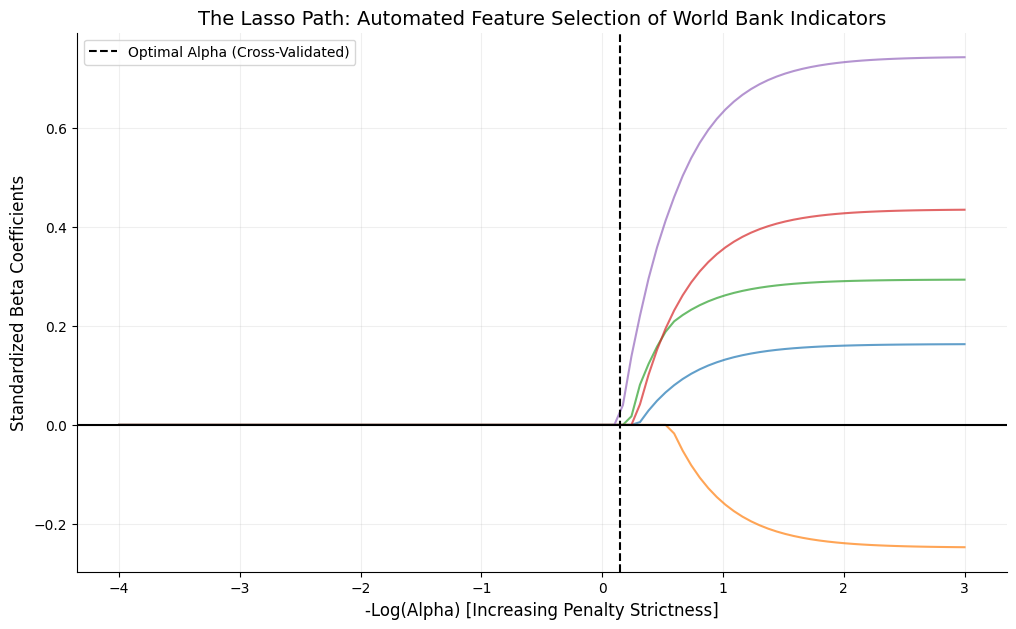

In [6]:

alphas_lasso, coefs_lasso, _ = lasso_path(X_scaled, y, alphas=alphas_to_test, max_iter=10000)

plt.figure(figsize=(12, 7))

for i in range(coefs_lasso.shape[0]):
    plt.plot(-np.log10(alphas_lasso), coefs_lasso[i, :], alpha=0.7)

plt.axvline(x=-np.log10(lasso_model.alpha_), color='black', linestyle='--', label='Optimal Alpha (Cross-Validated)')

plt.title('The Lasso Path: Automated Feature Selection of World Bank Indicators', fontsize=14)
plt.xlabel('-Log(Alpha) [Increasing Penalty Strictness]', fontsize=12)
plt.ylabel('Standardized Beta Coefficients', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5)
plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(alpha=0.2)

plt.show()